In [1]:
import pandas as pd
df = pd.read_csv("D:/tiger analytics/Practice data sets/cosutmer churn rate/customer_churn_business_dataset.csv") 

In [2]:
df.head(10)


,customer_id,gender,age,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,weekly_active_days,avg_session_time,...,avg_resolution_time,complaint_type,customer satsifaction score,escalations,email_open_rate,marketing_click_rate,net promoter score,survey_response,referral_count,churn
0,CUST_00001,Male,68,SME,22,Web,Monthly,26,7,11.762372,...,13.354360,Service,4,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Individual,9,Mobile,Monthly,7,5,26.846390,...,25.140088,Billing,2,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,SME,58,Web,Yearly,19,5,23.380065,...,27.572928,Service,3,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Individual,19,Mobile,Yearly,34,7,24.243136,...,26.420822,Technical,5,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Individual,52,Web,Monthly,20,6,18.872323,...,26.674579,Technical,4,0,0.65,0.44,21,Unsatisfied,1,0
5,CUST_00006,Female,36,Individual,54,Mobile,Monthly,1,3,20.938237,...,36.038391,Technical,4,1,0.83,0.05,-40,Neutral,1,0
6,CUST_00007,Male,23,SME,54,Mobile,Monthly,21,4,17.544416,...,36.892928,Billing,4,0,0.75,0.46,-3,Neutral,1,0
7,CUST_00008,Male,37,Individual,7,Referral,Yearly,17,7,26.188746,...,25.024133,Technical,4,1,0.54,0.13,28,Satisfied,1,0
8,CUST_00009,Male,44,SME,15,Referral,Monthly,29,4,1.000000,...,32.465536,Technical,2,0,0.85,0.13,-24,Satisfied,0,0
9,CUST_00010,Female,70,Individual,17,Mobile,Monthly,18,5,7.338150,...,42.986192,Billing,4,0,0.72,0.13,17,Neutral,1,0


In [3]:
df.drop(columns=["gender","customer_id"], inplace=True)

In [4]:
df["churn"] = df["churn"].astype(int)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           10000 non-null  int64  
 1   customer_segment              10000 non-null  object 
 2   tenure_months                 10000 non-null  int64  
 3   signup_channel                10000 non-null  object 
 4   contract_type                 10000 non-null  object 
 5   monthly_logins                10000 non-null  int64  
 6   weekly_active_days            10000 non-null  int64  
 7   avg_session_time              10000 non-null  float64
 8   features_used                 10000 non-null  int64  
 9   usage_growth_rate             10000 non-null  float64
 10  last_login_days_ago           10000 non-null  int64  
 11  monthly_fee                   10000 non-null  int64  
 12  total_revenue                 10000 non-null  int64  
 13  pa

In [6]:
X = pd.get_dummies(df, 
                   columns=[
                     "customer_segment",
                     "signup_channel",
                     "contract_type",
                       "payment_method",
                       "complaint_type"
                   ],
                   drop_first=True)

In [9]:
X.head()

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,...,customer_segment_Individual,customer_segment_SME,signup_channel_Referral,signup_channel_Web,contract_type_Quarterly,contract_type_Yearly,payment_method_Card,payment_method_PayPal,complaint_type_Service,complaint_type_Technical
0,68,22,26,7,11.762372,5,0.06,7,30,660,...,False,True,False,True,False,False,False,True,True,False
1,57,9,7,5,26.846390,1,-0.28,2,30,270,...,True,False,False,False,False,False,True,False,False,False
2,24,58,19,5,23.380065,6,0.13,23,20,1160,...,False,True,False,True,False,True,True,False,True,False
3,49,19,34,7,24.243136,2,-0.17,24,30,570,...,True,False,False,False,False,True,False,False,False,True
4,65,52,20,6,18.872323,2,-0.16,2,50,2600,...,True,False,False,True,False,False,False,True,False,True


In [10]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           10000 non-null  int64  
 1   tenure_months                 10000 non-null  int64  
 2   monthly_logins                10000 non-null  int64  
 3   weekly_active_days            10000 non-null  int64  
 4   avg_session_time              10000 non-null  float64
 5   features_used                 10000 non-null  int64  
 6   usage_growth_rate             10000 non-null  float64
 7   last_login_days_ago           10000 non-null  int64  
 8   monthly_fee                   10000 non-null  int64  
 9   total_revenue                 10000 non-null  int64  
 10  payment_failures              10000 non-null  int64  
 11  discount_applied              10000 non-null  object 
 12  price_increase_last_3m        10000 non-null  object 
 13  su

In [21]:
X['discount_applied'] = X['discount_applied'].map({'Yes': 1, 'No': 0})

In [22]:
X['price_increase_last_3m'] = X['price_increase_last_3m'].map({'Yes': 1, 'No': 0})

In [23]:
X["discount_applied"] = X["discount_applied"].astype(int)

In [24]:
X["price_increase_last_3m"] = X["price_increase_last_3m"].astype(int)

In [25]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           10000 non-null  int64  
 1   tenure_months                 10000 non-null  int64  
 2   monthly_logins                10000 non-null  int64  
 3   weekly_active_days            10000 non-null  int64  
 4   avg_session_time              10000 non-null  float64
 5   features_used                 10000 non-null  int64  
 6   usage_growth_rate             10000 non-null  float64
 7   last_login_days_ago           10000 non-null  int64  
 8   monthly_fee                   10000 non-null  int64  
 9   total_revenue                 10000 non-null  int64  
 10  payment_failures              10000 non-null  int64  
 11  discount_applied              10000 non-null  int64  
 12  price_increase_last_3m        10000 non-null  int64  
 13  su

In [27]:
X['survey_response'].value_counts()

survey_response
Satisfied      4975
Neutral        2978
Unsatisfied    2047
Name: count, dtype: int64

In [28]:
survey_map = {
    "Unsatisfied": 0,
    "Neutral": 1,
    "Satisfied": 2
}

X["survey_response"] = X["survey_response"].map(survey_map)

In [29]:
X['survey_response'].value_counts()

survey_response
2    4975
1    2978
0    2047
Name: count, dtype: int64

In [30]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           10000 non-null  int64  
 1   tenure_months                 10000 non-null  int64  
 2   monthly_logins                10000 non-null  int64  
 3   weekly_active_days            10000 non-null  int64  
 4   avg_session_time              10000 non-null  float64
 5   features_used                 10000 non-null  int64  
 6   usage_growth_rate             10000 non-null  float64
 7   last_login_days_ago           10000 non-null  int64  
 8   monthly_fee                   10000 non-null  int64  
 9   total_revenue                 10000 non-null  int64  
 10  payment_failures              10000 non-null  int64  
 11  discount_applied              10000 non-null  int64  
 12  price_increase_last_3m        10000 non-null  int64  
 13  su

In [31]:
y = X["churn"]

In [32]:
# Target variable


# Feature matrix (drop churn + ID if still present)
X = X.drop(columns=["churn"], errors="ignore")

In [33]:
y.head()

0    0
1    1
2    0
3    0
4    0
Name: churn, dtype: int64

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # VERY IMPORTANT
)


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [36]:

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced"     # protects rare churn class
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [37]:
print("📌 Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

📌 Random Forest Results:
Accuracy: 0.8805

Confusion Matrix:
 [[1721   75]
 [ 164   40]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.96      0.94      1796
           1       0.35      0.20      0.25       204

    accuracy                           0.88      2000
   macro avg       0.63      0.58      0.59      2000
weighted avg       0.86      0.88      0.87      2000



In [38]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance", ascending=False
)

feature_importance.head(20)

,Feature,Importance
15,customer satsifaction score,0.136049
1,tenure_months,0.102791
2,monthly_logins,0.094072
9,total_revenue,0.077953
10,payment_failures,0.068148
4,avg_session_time,0.048953
14,avg_resolution_time,0.048294
7,last_login_days_ago,0.044365
19,net promoter score,0.044126
17,email_open_rate,0.042050


In [39]:
# Identify numeric columns
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

# Standardize
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [40]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # handle class imbalance
    solver="lbfgs"
)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

In [41]:
print("📌 Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, log_pred))
print("\nClassification Report:\n", classification_report(y_test, log_pred))

📌 Logistic Regression Results:
Accuracy: 0.665

Confusion Matrix:
 [[1200  596]
 [  74  130]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.67      0.78      1796
           1       0.18      0.64      0.28       204

    accuracy                           0.67      2000
   macro avg       0.56      0.65      0.53      2000
weighted avg       0.86      0.67      0.73      2000



In [47]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Example model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Coefficients
coefficients = model.coef_[0]
intercept = model.intercept_[0]

# Show in table format
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': coefficients
})

print(coef_df)
print("\nIntercept:", intercept)


                         Feature  Coefficient
0                            age     0.034132
1                  tenure_months    -0.396662
2                 monthly_logins    -0.347885
3             weekly_active_days    -0.025018
4               avg_session_time     0.021724
5                  features_used     0.011960
6              usage_growth_rate     0.015094
7            last_login_days_ago     0.108972
8                    monthly_fee     0.023766
9                  total_revenue    -0.028991
10              payment_failures     0.319835
11              discount_applied    -0.038191
12        price_increase_last_3m     0.010725
13               support_tickets    -0.005871
14           avg_resolution_time    -0.051669
15  customer satsifaction score     -0.582584
16                   escalations     0.016914
17               email_open_rate     0.011384
18          marketing_click_rate    -0.001839
19           net promoter score      0.041554
20               survey_response  

In [45]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})


coef_df = coef_df.reindex(coef_df.Coefficient.abs().sort_values(ascending=False).index)
print(coef_df)

                         Feature  Coefficient
15  customer satsifaction score     -0.421607
10              payment_failures     0.161694
3             weekly_active_days    -0.074994
21                referral_count    -0.039543
5                  features_used    -0.037566
2                 monthly_logins    -0.027041
22   customer_segment_Individual    -0.023913
25            signup_channel_Web    -0.023151
20               survey_response    -0.022791
13               support_tickets    -0.021865
11              discount_applied    -0.018155
7            last_login_days_ago     0.017878
23          customer_segment_SME     0.016951
26       contract_type_Quarterly    -0.015756
1                  tenure_months    -0.015127
4               avg_session_time     0.015058
30        complaint_type_Service    -0.014332
24       signup_channel_Referral     0.009373
31      complaint_type_Technical    -0.007869
14           avg_resolution_time    -0.007743
8                    monthly_fee  

In [48]:
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': model.coef_[0]
})


coef_df = coef_df.reindex(coef_df.Coefficient.abs().sort_values(ascending=False).index)
print(coef_df)

                         Feature  Coefficient
15  customer satsifaction score     -0.582584
1                  tenure_months    -0.396662
2                 monthly_logins    -0.347885
10              payment_failures     0.319835
23          customer_segment_SME     0.240119
28           payment_method_Card     0.143207
30        complaint_type_Service    -0.143018
7            last_login_days_ago     0.108972
29         payment_method_PayPal     0.101817
24       signup_channel_Referral     0.090981
22   customer_segment_Individual     0.088613
26       contract_type_Quarterly    -0.070959
31      complaint_type_Technical    -0.065481
14           avg_resolution_time    -0.051669
19           net promoter score      0.041554
21                referral_count    -0.040106
11              discount_applied    -0.038191
0                            age     0.034132
25            signup_channel_Web    -0.029297
9                  total_revenue    -0.028991
3             weekly_active_days  

<Axes: xlabel='churn', ylabel='tenure_months'>

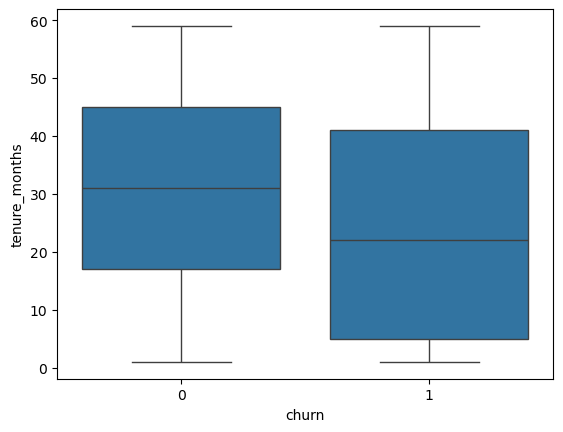

In [50]:
import seaborn as sns
sns.boxplot(x='churn', y='tenure_months', data=df)

In [65]:
top_features = X[["customer satsifaction score ", "tenure_months", "payment_failures", "monthly_logins"]]


In [58]:
for col in top_features:
    print(col, df.groupby('churn')[col].mean())

customer satsifaction score  churn
0    3.538813
1    3.028404
Name: customer satsifaction score , dtype: float64
tenure_months churn
0    30.830382
1    24.222331
Name: tenure_months, dtype: float64
payment_failures churn
0    0.473995
1    0.738492
Name: payment_failures, dtype: float64
monthly_logins churn
0    19.998218
1    16.803134
Name: monthly_logins, dtype: float64


In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = X[top_features + ["churn"]]     # combine features + churn

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data.corr(), annot=True, cmap='coolwarm', linewidths=1)
plt.title("Correlation Heatmap – Top 5 Features vs Churn")
plt.show()

ValueError: Unable to coerce to Series, length must be 4: given 1

In [70]:
X.columns.tolist()

['age',
 'tenure_months',
 'monthly_logins',
 'weekly_active_days',
 'avg_session_time',
 'features_used',
 'usage_growth_rate',
 'last_login_days_ago',
 'monthly_fee',
 'total_revenue',
 'payment_failures',
 'discount_applied',
 'price_increase_last_3m',
 'support_tickets',
 'avg_resolution_time',
 'customer satsifaction score ',
 'escalations',
 'email_open_rate',
 'marketing_click_rate',
 'net promoter score ',
 'survey_response',
 'referral_count',
 'customer_segment_Individual',
 'customer_segment_SME',
 'signup_channel_Referral',
 'signup_channel_Web',
 'contract_type_Quarterly',
 'contract_type_Yearly',
 'payment_method_Card',
 'payment_method_PayPal',
 'complaint_type_Service',
 'complaint_type_Technical']

In [71]:
df.rename(columns={"customer satsifaction score ": "customer_satisfaction_score"}, inplace=True)

In [72]:
top_features = [
    "customer_satisfaction_score",
    "tenure_months",
    "monthly_logins",
    "total_revenue",
    "payment_failures"
]

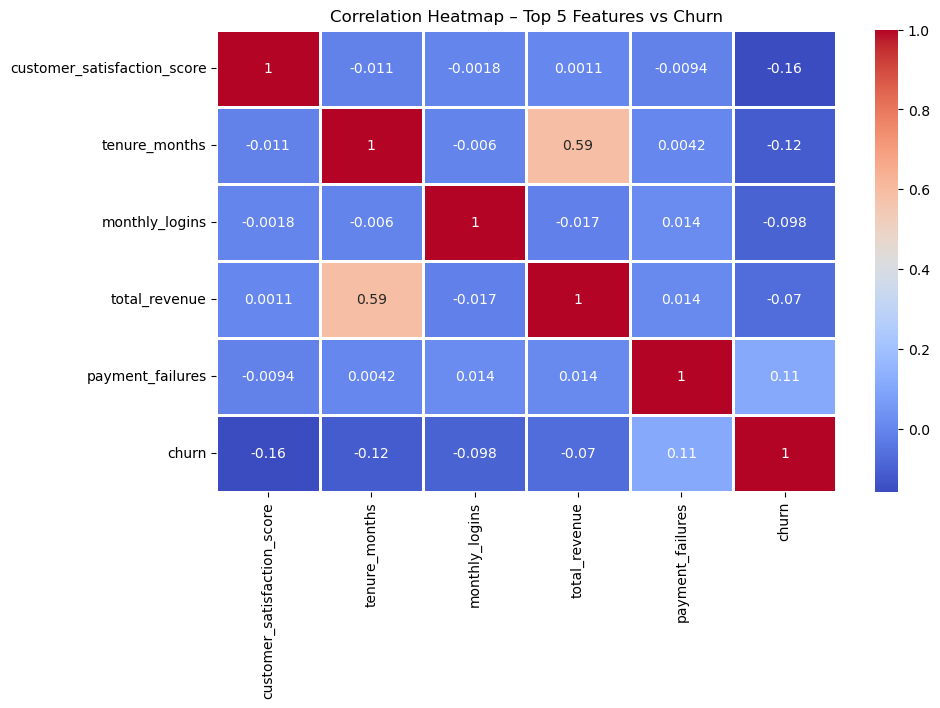

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = df[top_features + ["churn"]]

plt.figure(figsize=(10,6))
sns.heatmap(
    heatmap_data.corr(), 
    annot=True, 
    cmap="coolwarm", 
    linewidths=1
)
plt.title("Correlation Heatmap – Top 5 Features vs Churn")
plt.show()

In [74]:
pip install scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [75]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

In [81]:
features_for_pdp = [
    "customer satsifaction score ",
    "tenure_months",
    "monthly_logins",
    "total_revenue",
    "payment_failures"
]

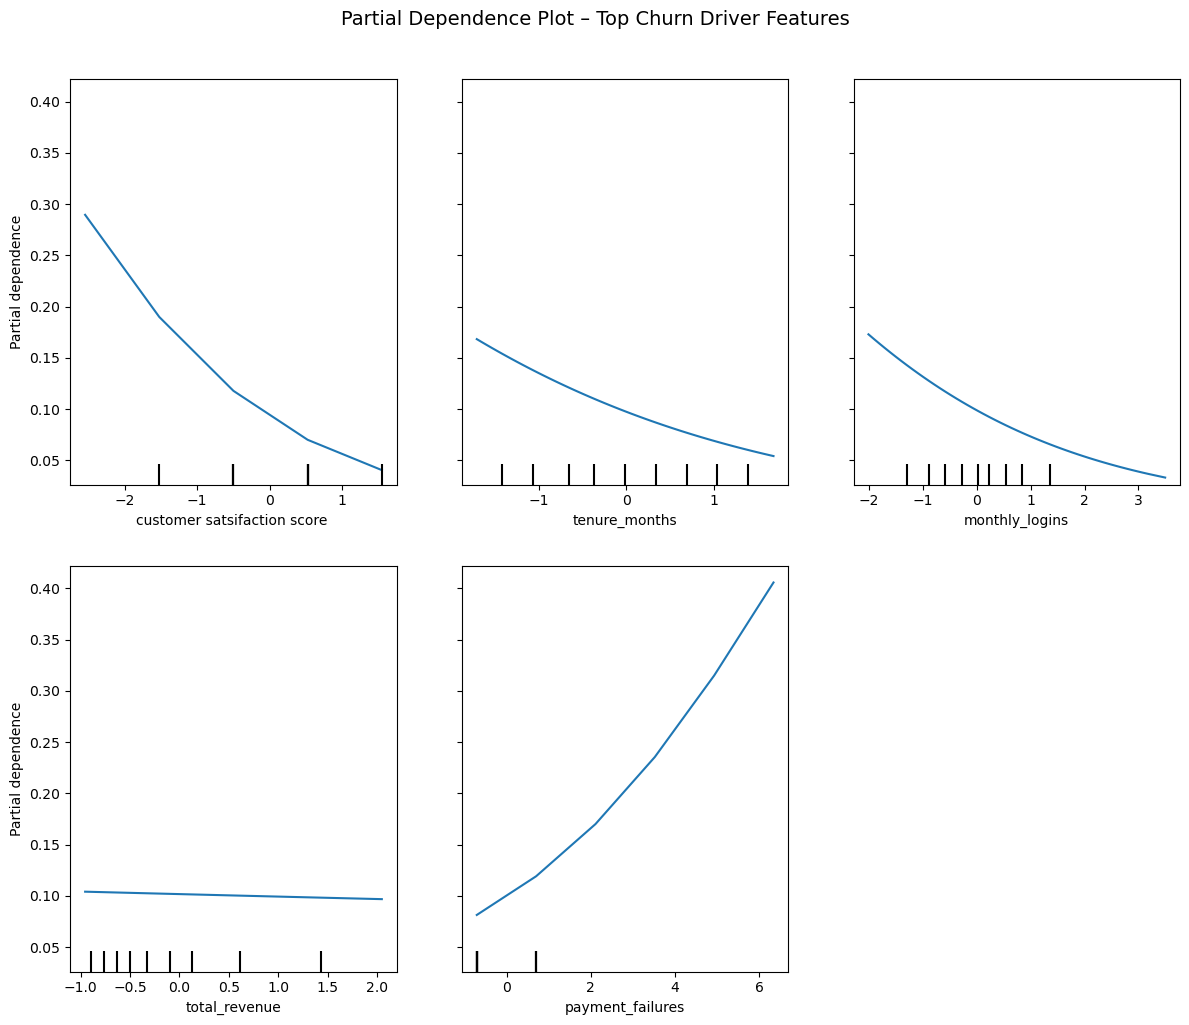

In [83]:
fig, ax = plt.subplots(figsize=(12, 10))

PartialDependenceDisplay.from_estimator(
    model,
    X_train_scaled,
    features_for_pdp,
    ax=ax
)

plt.suptitle("Partial Dependence Plot – Top Churn Driver Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# PDP 
#If we increase this feature while keeping all other variables constant, how does churn probability change?”

Y–axis :  Predicted churn probability — model output.

#1️⃣ Upward slope

📈
→ As feature increases, churn probability increases.
Example:
payment_failures ↑ → churn risk ↑

Meaning: customers who struggle with payments are likely to leave.

2️⃣ Downward slope

📉
→ As feature increases, churn probability decreases.
Example:
tenure_months ↑ → churn risk ↓

Meaning: long-term customers are more stable.

3️⃣ Flat / near zero

—
→ Feature has weak or no effect on churn.
Model isn’t sensitive to changes in that feature.

4️⃣ U-shape or inverted U

U or ∩
→ Medium values have different churn behavior than low/high values.
Indicates non-linear relationship.